#ML4Net - Lab 2

## Team members

Felipe López 266687 | Raúl Martin 267819 | Melker Svensson 3 242994

## Description

In this lab, you will implement an ML model that detects congestion in Wi-Fi networks. In particular, you will desing and implement a supervised learning model (e.g., linear regression, multi-layer perceptron, neural network), which you will train using a dataset that was generated using the ns-3 simulator.

Each row in the dataset is organized as (x1, x2, ..., x26, y1, y2, ..., y26, s, r, l), where:

* `x1, x2..., x26, y1, y2, ..., y26` represent the histogram of the Inter-Frame Space (IFS) values for M frames that accessed the medium in a 60 seconds observation sample.
  * `x26` represents the maximum IFS duration (in ms) in the considered M frames whereas `x1` is `x26`/26
  * The remaining `xi` values are buckets at uniform spacing between `x1` and `x26`.
  * For i>1, the values of `yi` represent the IFS histogram count (in percentage) for a corresponding bucket interval between `xi`-1 and `xi`.
  * In the case of `y1`, the bucket interval is between 0 and `x1`
* `s` is the average IFS duration (in ms)
* `r` is the percentage of frame collisions
* `l` is the label, where 1 indicates that the network is saturated, and 0, that it is not

Original dataset: https://ieee-dataport.org/documents/dataset-identification-saturated-and-unsaturated-wi-fi-networks

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 21 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [ ]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip

--2026-05-17 15:32:37--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip [following]
--2026-05-17 15:32:38--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1803279 (1.7M) [application/zip]
Saving to: ‘dataset_Lab2.zip’

dataset_Lab2.zip    100%[===================>]   1.72M  --.-KB/s    in 0.02s   

2026-05-17 15:32:38 (81.5 MB/

3. Define the main path of the code

In [ ]:
mypath="drive/MyDrive/AAX/Lab2"

4. Extract the source code to the destination folder

In [ ]:
mkdir $mypath; cp dataset_Lab2.zip $mypath; cd $mypath; unzip dataset_Lab2.zip

mkdir: cannot create directory ‘drive/MyDrive/AAX/Lab2’: File exists
Archive:  dataset_Lab2.zip
replace test_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Visualizing the data




       0       1       2       3       4       5       6       7       8   \
0  0.0065  0.0130  0.0195  0.0260  0.0325  0.0390  0.0455  0.0520  0.0585   
1  0.0263  0.0526  0.0789  0.1052  0.1316  0.1579  0.1842  0.2105  0.2368   
2  0.0176  0.0352  0.0528  0.0704  0.0881  0.1057  0.1233  0.1409  0.1585   
3  0.0222  0.0444  0.0666  0.0888  0.1110  0.1332  0.1554  0.1776  0.1998   
4  0.0189  0.0379  0.0568  0.0758  0.0947  0.1137  0.1326  0.1516  0.1705   

       9   ...      45      46      47      48      49      50      51  \
0  0.0650  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
1  0.2631  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
2  0.1761  ...  0.0316  0.0368  0.0312  0.0312  0.0316  0.0299  0.0304   
3  0.2220  ...  0.0316  0.0307  0.0312  0.0000  0.0360  0.0364  0.0304   
4  0.1895  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   

       52      53  54  
0  0.0604  0.9960   1  
1  0.0604  0.9960   1  
2  0.0604  0.9957   

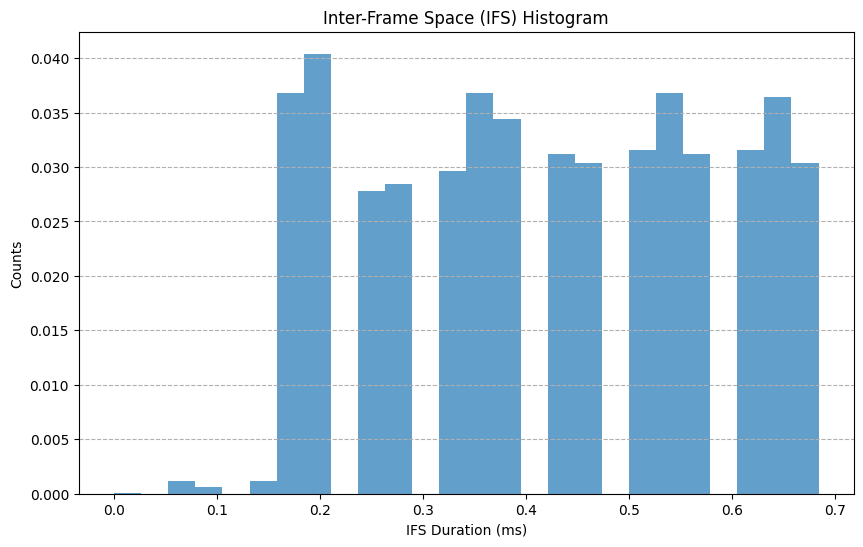

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ifs_histogram(data_row):
    """
    Plots the Inter-Frame Space (IFS) histogram from a single row of the dataset.

    Args:
        data_row (list or numpy.ndarray): A list or array representing a single row
                                          in the format (x1, ..., x26, y1, ..., y26, s, r, l).
    """

    # Get IFS values and the corresponding counts
    x_values = np.array(data_row[:26])
    y_counts = np.array(data_row[26:52])

    # Calculate the bin edges based on x_values
    bin_edges = [0] + list(x_values)

    # Create the histogram plot
    plt.figure(figsize=(10, 6))
    plt.bar(bin_edges[:-1], y_counts, width=np.diff(bin_edges)[0], align='edge', alpha=0.7)

    # Add labels and title
    plt.xlabel("IFS Duration (ms)")
    plt.ylabel("Counts")
    plt.title("Inter-Frame Space (IFS) Histogram")
    plt.grid(axis='y', linestyle='--')

    # Show the plot
    plt.show()

# Example usage

# -> Read the data file
file_name = mypath + '/train_data.csv'
train_data_df = pd.read_csv(file_name, header=None)
print(train_data_df.head())

# -> Get a sample from the dataset and plot it
row_index = 1
sample_data = train_data_df.iloc[row_index].values
plot_ifs_histogram(sample_data)

## EXERCISES

### Exercise 1:
Define an approach for training and validating the model you are going to train with the proposed data. Then, perform the split accordingly.

In [ ]:
# We will use the provided train_data.csv datset for trainging and validation and we will reserve test_data.csv for testing

#The training datesat is split into 80% training and 20% validation. We used stratisfied splitting to keep the same proportion of saturated and not saturated samples in both subsets.

from sklearn.model_selection import train_test_split

# Load the datasets
train_data_df = pd.read_csv(mypath + "/train_data.csv", header=None)
test_data_df = pd.read_csv(mypath + "/test_data.csv", header=None)

# Split features and labels
# Columns 0 to 53 are input features and column 54 is the label
X = train_data_df.iloc[:, :-1]
y = train_data_df.iloc[:, -1]

X_test = test_data_df.iloc[:, :-1]
y_test = test_data_df.iloc[:, -1]

#Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print("Test samples:", X_test.shape)

Training samples: (16000, 54)
Validation samples: (4000, 54)
Test samples: (500, 54)


### Exercise 2:

Define your ML model, so that it can be called for training and test. Examples of approaches that you could use (but not limited to):

*   Logistic Regression
*   K-Nearest Neighbors (KNN)
*   Decision Trees or Random Forests
*   Convolutional Neural Network (CNN)

In [ ]:
# We define a Logistic Regression model because the goal is to check if it is saturated or not so it is a binary classification problem
#The Wi-Fi network could besaturated (1) or not saturated (0).
# A StandardScaler is included to normalize the input features before training, which improves the behavior of linear models

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


### Exercise 3:

Define the hyperparameters that you will use to train the model.

In [ ]:
#I will use max_iter = 1000: This is the maximum number of iterations the optimizer has to converge. Having a high value avoids convergence warnings during the training

#random_state= 42 : this ensures reproducibility of the results by fixing the random seed.

#We as well use StandardScaler to normalize the features before training

#Logistic Regression applies L2 regularization by default with C = 1, this helps reduce overfitting and improve generalization.


### Exercise 4:
Train the model and show the procedure (e.g., evolution of the training/validation loss).

In [ ]:
from sklearn.metrics import accuracy_score

#Training the model
model.fit(X_train, y_train)

# Predictions on training and validation sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

#Compute accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

Training Accuracy: 0.981875
Validation Accuracy: 0.97875


In [ ]:
from sklearn.metrics import log_loss

# Predicted probabilities
y_train_prob = model.predict_proba(X_train)
y_val_prob = model.predict_proba(X_val)

# Compute log loss
train_loss = log_loss(y_train, y_train_prob)
val_loss = log_loss(y_val, y_val_prob)

print("Training Log-Loss:", train_loss)
print("Validation Log-Loss:", val_loss)

Training Loss: 0.0585137564209248
Validation Loss: 0.06583703043447733


This model achieves high accuracy on both the training and validation sets. They are as well very similar which means that the model generalizes well and does not suffer from overfitting. The log-loss values are also low and close between both datasets showing that the model predictions are confident and consistent.

### Exercise 5:

Select and define the most appropriate evaluation metric(s). Discuss the appropriateness of your evaluation metrics for the binary classification problem we are considering.

In [ ]:
# We used accuracy and log-loss as the main evaluation metrics for this binary classification problem.

#Accuraccy measures the proportion of correctly classified samples. It is useful because the objective of the model is literally that,
#to correctly identify whether the Wi-Fi network is saturated or not.

#Logloss evaluates the confidence of the predicted probabilites.
#We have very low values on that metric which means that the model is confident on the correct decisions it makes.


#So we can conclude that the model has a good classification performance and the quality and confidence on its predictions are very good as well.

### Exercise 6:

Evaluate your trained model on the test set, using the evaluation metrics that you have proposed. Remember that the test data should have not been seen by the model, so that we can properly estimate of its generalization capabilities.

In [ ]:
from sklearn.metrics import accuracy_score, log_loss

# Predictions on the test set
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)

# Compute test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_loss = log_loss(y_test, y_test_prob)

print("Test Accuracy:", test_accuracy)
print("Test Log-Loss:", test_loss)

Test Accuracy: 0.918
Test Log-Loss: 0.18819607242226316


The model achieves good performance on the unseen test dataset with 91.8% of accuracy.

Is lower than the training and validation accuracy but is a normal thing because this is on unseen data. However the model generalizes well.

The increase on the log-loss suggests that the model is not as confident when making the classiffications on unseen samples, but overall the predictions remain reliable.